exp 4

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
# Load the Breast Cancer Wisconsin dataset as a DataFrame
cancer = load_breast_cancer(as_frame=True)

# Get the complete DataFrame
df = cancer.frame

# Display basic information about the dataset
print("Shape of dataset:", df.shape)

print("\nFeature Names:")
print(cancer.feature_names)

print("\nTarget Names:")
print(cancer.target_names)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst Five Rows:")
display(df.head())

Shape of dataset: (569, 31)

Feature Names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target Names:
['malignant' 'benign']

Missing Values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Separate input features and target variable
X = df.drop("target", axis=1)
y = df["target"]

# Display their shapes
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (569, 30)
Shape of y: (569,)


In [4]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the shapes of the split datasets
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (455, 30)
X_test shape : (114, 30)
y_train shape: (455,)
y_test shape : (114,)


In [5]:
# Create a StandardScaler object
scaler = StandardScaler()

# Learn scaling parameters from the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaling parameters to transform the test data
X_test_scaled = scaler.transform(X_test)

# Display the shapes
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

X_train_scaled shape: (455, 30)
X_test_scaled shape : (114, 30)


In [6]:
# Create a Logistic Regression model using MLE (no regularization)
mle_model = LogisticRegression(
    penalty=None,
    max_iter=1000,
    random_state=42
)

# Train the model
mle_model.fit(X_train_scaled, y_train)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict the class labels for the test set
y_pred_mle = mle_model.predict(X_test_scaled)

# Calculate the accuracy
accuracy_mle = accuracy_score(y_test, y_pred_mle)

print("MLE Accuracy:", accuracy_mle)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_mle))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_mle))


MLE Accuracy: 0.9210526315789473

Confusion Matrix:
[[40  2]
 [ 7 65]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.95      0.90        42
           1       0.97      0.90      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.93      0.92       114
weighted avg       0.93      0.92      0.92       114



In [8]:
# Create Logistic Regression model using MAP with L2 regularization
l2_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000,
    random_state=42
)

# Train the L2 regularized model
l2_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict using the L2 regularized model
y_pred_l2 = l2_model.predict(X_test_scaled)

# Calculate L2 model accuracy
accuracy_l2 = accuracy_score(y_test, y_pred_l2)

print("L2 MAP Accuracy:", accuracy_l2)

print("\nL2 MAP Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_l2))

print("\nL2 MAP Classification Report:")
print(classification_report(y_test, y_pred_l2))


L2 MAP Accuracy: 0.9824561403508771

L2 MAP Confusion Matrix:
[[41  1]
 [ 1 71]]

L2 MAP Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [10]:
# Create Logistic Regression model using MAP with L1 regularization
l1_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=1.0,
    max_iter=1000,
    random_state=42
)

# Train the L1 regularized model
l1_model.fit(X_train_scaled, y_train)


,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
# Get feature names
features = X.columns

# Create a DataFrame comparing coefficients
coefficients = pd.DataFrame({
    "Feature": features,
    "MLE": mle_model.coef_[0],
    "L2_MAP": l2_model.coef_[0],
    "L1_MAP": l1_model.coef_[0]
})

# Display first few coefficients
coefficients.head(10)

,Feature,MLE,L2_MAP,L1_MAP
0,mean radius,17.577291,-0.511479,0.000000
1,mean texture,-98.509304,-0.552698,-0.397179
2,mean perimeter,15.647759,-0.476298,0.000000
3,mean area,-35.595201,-0.541059,0.000000
4,mean smoothness,-53.595641,-0.212479,0.000000
5,mean compactness,360.412168,0.648342,0.000000
6,mean concavity,-98.488666,-0.602103,0.000000
7,mean concave points,-35.337466,-0.704156,-0.489200
8,mean symmetry,-19.316888,-0.167233,0.000000
9,mean fractal dimension,-107.354640,0.199732,0.080631


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Store predictions from all models
models = {
    "MLE": y_pred_mle,
    "MAP_L2": y_pred_l2,
    "MAP_L1": l1_model.predict(X_test_scaled)
}

# Create comparison table
results = []

for name, prediction in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction),
        "Recall": recall_score(y_test, prediction),
        "F1 Score": f1_score(y_test, prediction)
    })

comparison = pd.DataFrame(results)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,MLE,0.921053,0.970149,0.902778,0.935252
1,MAP_L2,0.982456,0.986111,0.986111,0.986111
2,MAP_L1,0.991228,0.986301,1.000000,0.993103


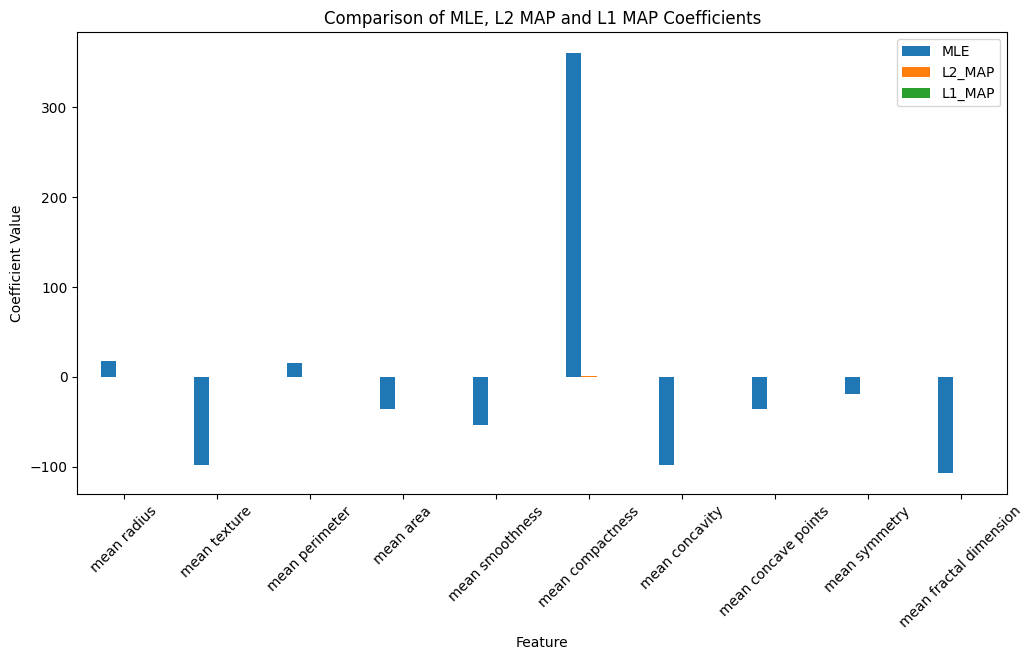

In [13]:
# Plot first 10 feature coefficients

comparison_coeff = coefficients.head(10)

comparison_coeff.set_index("Feature").plot(
    kind="bar",
    figsize=(12,6)
)


plt.title(
    "Comparison of MLE, L2 MAP and L1 MAP Coefficients"
)

plt.ylabel(
    "Coefficient Value"
)

plt.xticks(
    rotation=45
)

plt.show()